## Plotting spring time series for event selection

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns  
from sklearn.linear_model import LinearRegression
from scipy.signal import find_peaks, peak_prominences

# tau
tau = pd.read_csv('../../data/shear_stress/average_total_shear_stress_corrected.csv', parse_dates=['datetime'], index_col='datetime')
# sonde data
down_sonde = pd.read_csv('../../data/sonde_data/sonde_down_full_record_smoothed.csv', parse_dates=['DateTime'], index_col='DateTime')
up_sonde = pd.read_csv('../../data/sonde_data/sonde_up_full_record_smoothed.csv', parse_dates=['DateTime'], index_col='DateTime')
# nutrient data
down_constituents = pd.read_csv('../../data/constituents/SP23_down_constituents.csv', parse_dates=['Date_Time'], index_col='Date_Time')
up_constituents = pd.read_csv('../../data/constituents/SP23_up_constituents.csv', parse_dates=['Date_Time'], index_col='Date_Time')

storm_directory = '../../data/constituents'
storms = {}
for filename in os.listdir(storm_directory):
    # check if the file is a CSV file
    if filename.endswith('.csv'):
        file_path = os.path.join(storm_directory, filename) # construct the full file path
        df = pd.read_csv(file_path)                         # read the CSV file into a data frame
        df = df.dropna(subset=['Date_Time'])                # drop rows where 'Date/Time' is NaN  
        df['Date_Time'] = pd.to_datetime(df['Date_Time'])   # convert to datetime format
        df = df.set_index('Date_Time')                      # set date time as the index 
        df = df.dropna(how='all', axis=1)                   # drop columns where all values are NaN
        key = filename[:-4]                                 # remove the '.csv' from the filename to use as the dictionary key
        storms[key] = df                                    # store the data frame in the dictionary

# in sonde data sets, delete rows with negative data 
down_sonde = down_sonde[(down_sonde['Turbidity FNU'] >= 0) & (down_sonde['fDOM RFU'] >= 0) & (down_sonde['Turbidity FNU'] <= 100)]
up_sonde = up_sonde[(up_sonde['Turbidity FNU'] >= 0) & (up_sonde['fDOM RFU'] >= 0) & (up_sonde['Turbidity FNU'] <= 100)]
tau = tau[(tau['shear_stress'] >= 55)]

Turbidity Time Series

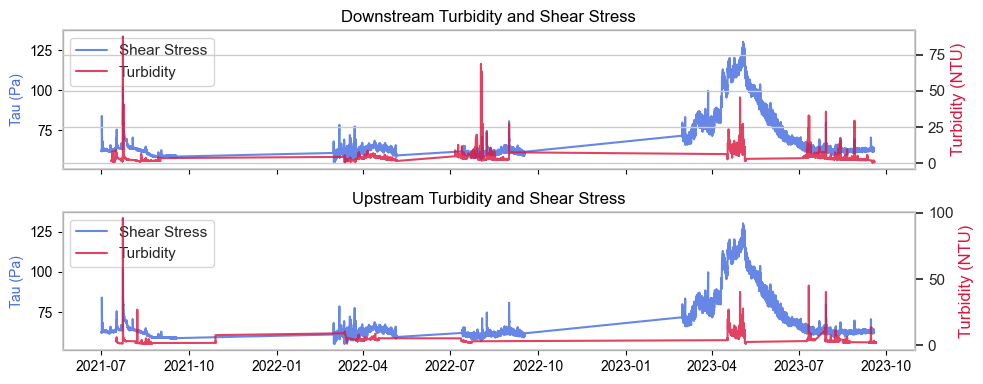

In [2]:
# plot tau and turbidity time series for reaches
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
sns.set_theme(style="whitegrid")
colors = ['royalblue', 'crimson']
labels = ['Shear Stress', 'Turbidity']
ylabels = ['Tau (Pa)', 'Turbidity (NTU)']
data = [down_sonde, up_sonde]
titles = ['Downstream Turbidity and Shear Stress', 'Upstream Turbidity and Shear Stress']

for i, sonde in enumerate(data):
    ax_tau = ax[i]
    ax_turb = ax_tau.twinx()

    ax_tau.plot(tau.index, tau['shear_stress'], label=labels[0], color=colors[0], alpha=0.8)
    ax_tau.set_ylabel(ylabels[0], color=colors[0])
    ax_tau.grid(False)

    ax_turb.plot(sonde.index, sonde['Turbidity FNU'], label=labels[1], color=colors[1], alpha=0.8)
    ax_turb.set_ylabel(ylabels[1], color=colors[1])

    ax_tau.set_title(titles[i])
    lines, labs = ax_tau.get_legend_handles_labels()
    lines2, labs2 = ax_turb.get_legend_handles_labels()
    ax_tau.legend(lines + lines2, labs + labs2, loc='upper left')

plt.grid(False)
plt.tight_layout()
plt.show()

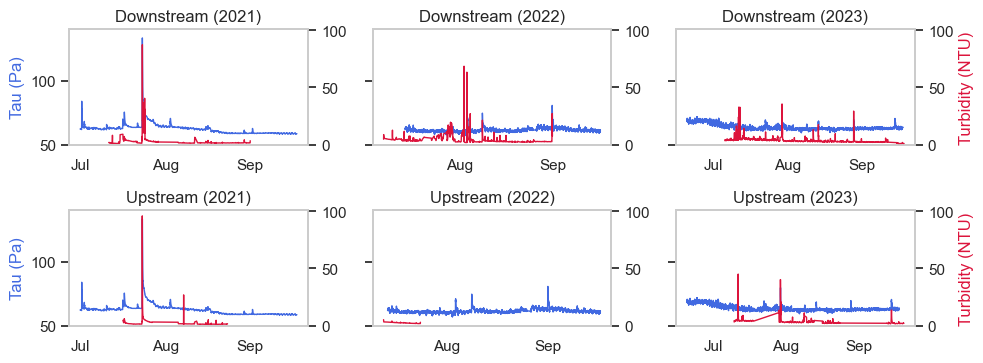

In [3]:
sns.set_theme(style="whitegrid")
years = [2021, 2022, 2023]
turb_max = max(down_sonde["Turbidity FNU"].max(), up_sonde["Turbidity FNU"].max())
tau_max = tau["shear_stress"].max()

fig, axes = plt.subplots(2, 3, figsize=(10, 4), sharey='row')
data = [(down_sonde, "Downstream"), (up_sonde, "Upstream")]

for row, (sonde, reach_name) in enumerate(data):
    for col, year in enumerate(years):
        ax_tau = axes[row, col]
        ax_turb = ax_tau.twinx()
        start = pd.Timestamp(f"{year}-06-20")
        end   = pd.Timestamp(f"{year}-09-20")

        # subset shear stress
        tau_sub = tau.loc[start:end]
        # subset turbidity
        sonde_sub = sonde.loc[start:end]

        # shear stress
        ax_tau.plot(tau_sub.index, tau_sub["shear_stress"], color="royalblue", lw=1, label="Shear Stress")
        ax_tau.xaxis.set_major_locator(mdates.MonthLocator())
        ax_tau.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        # turbidity
        ax_turb.plot(sonde_sub.index, sonde_sub["Turbidity FNU"], color="crimson", lw=1, label="Turbidity")
        
        # titles
        if row == 0:
            ax_tau.set_title(f"{year}")
        # row labels
        if col == 0:
            ax_tau.set_ylabel("Tau (Pa)", color="royalblue")
        if col == 2:
            ax_turb.set_ylabel("Turbidity (NTU)", color="crimson")
        # reach label on left side
        ax_tau.set_title(f"{reach_name} ({year})")
        ax_tau.grid(False)
        ax_turb.grid(False)
        ax_turb.set_ylim(0, turb_max * 1.05)
        ax_tau.set_ylim(50, tau_max * 1.05)
        

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fDOM Time Series

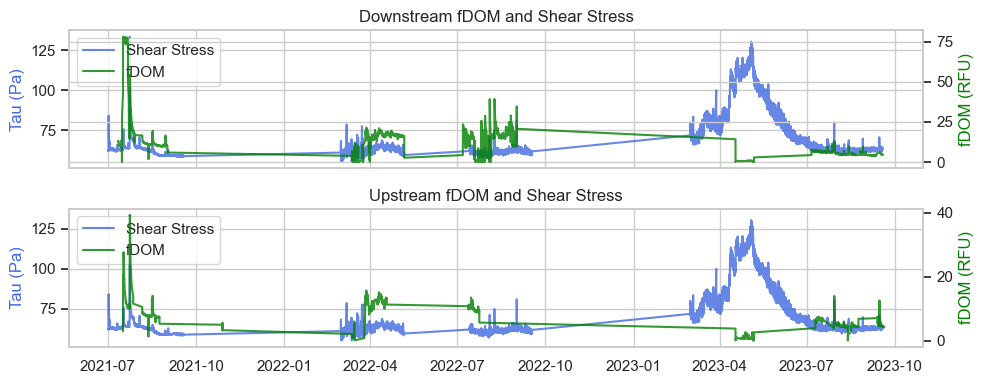

In [4]:
# plot tau and turbidity time series for reaches
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
sns.set_theme(style="whitegrid")
colors = ['royalblue', 'green']
labels = ['Shear Stress', 'fDOM']
ylabels = ['Tau (Pa)', 'fDOM (RFU)']
data = [down_sonde, up_sonde]
titles = ['Downstream fDOM and Shear Stress', 'Upstream fDOM and Shear Stress']

for i, sonde in enumerate(data):
    ax_tau = ax[i]
    ax_turb = ax_tau.twinx()

    ax_tau.plot(tau.index, tau['shear_stress'], label=labels[0], color=colors[0], alpha=0.8)
    ax_tau.set_ylabel(ylabels[0], color=colors[0])
    ax_tau.grid(True)

    ax_turb.plot(sonde.index, sonde['fDOM RFU'], label=labels[1], color=colors[1], alpha=0.8)
    ax_turb.set_ylabel(ylabels[1], color=colors[1])

    ax_tau.set_title(titles[i])
    lines, labs = ax_tau.get_legend_handles_labels()
    lines2, labs2 = ax_turb.get_legend_handles_labels()
    ax_tau.legend(lines + lines2, labs + labs2, loc='upper left')

plt.grid(False)
plt.tight_layout()
plt.show()

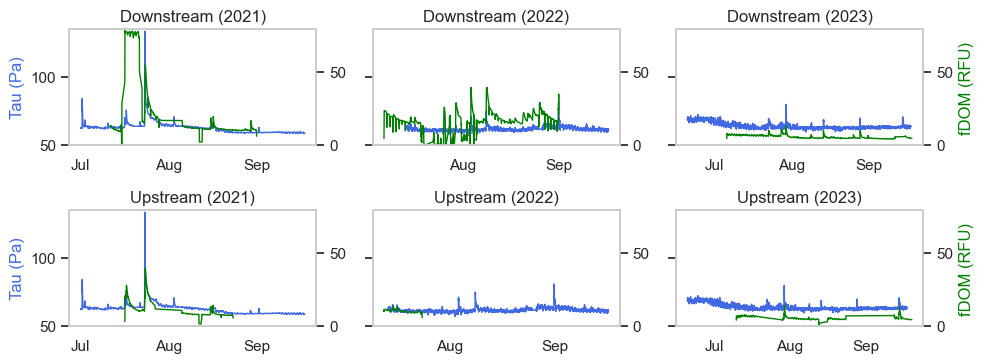

In [5]:
sns.set_theme(style="whitegrid")
years = [2021, 2022, 2023]
fdom_max = max(down_sonde["fDOM RFU"].max(), up_sonde["fDOM RFU"].max())
tau_max = tau["shear_stress"].max()

fig, axes = plt.subplots(2, 3, figsize=(10, 4), sharey='row')
data = [(down_sonde, "Downstream"), (up_sonde, "Upstream")]

for row, (sonde, reach_name) in enumerate(data):
    for col, year in enumerate(years):
        ax_tau = axes[row, col]
        ax_turb = ax_tau.twinx()
        start = pd.Timestamp(f"{year}-06-20")
        end   = pd.Timestamp(f"{year}-09-20")

        # subset shear stress
        tau_sub = tau.loc[start:end]
        # subset turbidity
        sonde_sub = sonde.loc[start:end]

        # shear stress
        ax_tau.plot(tau_sub.index, tau_sub["shear_stress"], color="royalblue", lw=1, label="Shear Stress")
        ax_tau.xaxis.set_major_locator(mdates.MonthLocator())
        ax_tau.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        # turbidity
        ax_turb.plot(sonde_sub.index, sonde_sub["fDOM RFU"], color="green", lw=1, label="fDOM")
        
        # titles
        if row == 0:
            ax_tau.set_title(f"{year}")
        # row labels
        if col == 0:
            ax_tau.set_ylabel("Tau (Pa)", color="royalblue")
        if col == 2:
            ax_turb.set_ylabel("fDOM (RFU)", color="green")
        # reach label on left side
        ax_tau.set_title(f"{reach_name} ({year})")
        ax_tau.grid(False)
        ax_turb.grid(False)
        ax_turb.set_ylim(0, fdom_max * 1.01)
        ax_tau.set_ylim(50, tau_max * 1.01)
        

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Determining event peaks

In [6]:
# define storm windows once
storm_windows = {
    "st1": ("2021-07-23 12:30", "2021-07-28 11:15"),
    "st2": ("2022-08-03 15:00", "2022-08-03 19:00"),
    "st3": ("2022-08-08 12:30", "2022-08-08 22:15"),
    "st4": ("2023-07-29 13:00", "2023-07-30 10:30"),
    "st5": ("2023-08-13 17:15", "2023-08-14 03:15"),
    "st6": ("2023-08-28 11:30", "2023-08-28 16:30"),
    "st7": ("2023-09-14 13:00", "2023-09-15 13:00")
}

# resample discharge to 1 min to have matching time steps with sonde data 
tau_resampled = tau.resample('1min').interpolate()
# merge shear stress to the sonde dataframe 
down_sonde = down_sonde.merge(tau_resampled, left_index=True, right_index=True, how='left')
up_sonde = up_sonde.merge(tau_resampled, left_index=True, right_index=True, how='left')
up_sonde

,Turbidity FNU,fDOM RFU,shear_stress
DateTime,,,
2021-07-16 15:15:00,4.7820,2.898000,68.166332
2021-07-16 15:30:00,4.8080,7.012000,68.090157
2021-07-16 15:45:00,4.7500,11.222000,67.938042
2021-07-16 16:00:00,4.6600,15.426000,67.786249
2021-07-16 16:15:00,4.5520,19.630000,67.634781
...,...,...,...
2023-09-19 22:45:00,2.1540,4.326000,NaN
2023-09-19 23:00:00,2.1400,4.324000,NaN
2023-09-19 23:15:00,2.1180,4.320000,NaN


In [7]:
peak_rows = []
for storm_name, (start, end) in storm_windows.items():
    # subset tau record to event window
    event_tau = tau.loc[start:end, "shear_stress"]
    # skip empty windows
    if event_tau.empty:
        peak_rows.append({
            "storm": storm_name,
            "start": start,
            "end": end,
            "peak_tau": pd.NA,
            "peak_time": pd.NaT
        })
        continue

    # peak value and timestamp
    peak_tau = event_tau.max()
    peak_time = event_tau.idxmax()

    peak_rows.append({
        "storm": storm_name,
        "start": pd.Timestamp(start),
        "end": pd.Timestamp(end),
        "peak_tau": peak_tau,
        "peak_time": peak_time,
        "max_turbidity_down": down_sonde.loc[start:end, "Turbidity FNU"].max(),
        "max_turbidity_up": up_sonde.loc[start:end, "Turbidity FNU"].max(),
        "max_fdom_down": down_sonde.loc[start:end, "fDOM RFU"].max(),
        "max_fdom_up": up_sonde.loc[start:end, "fDOM RFU"].max()
    })

peak_tau_df = pd.DataFrame(peak_rows)
peak_tau_df

,storm,start,end,peak_tau,peak_time,max_turbidity_down,max_turbidity_up,max_fdom_down,max_fdom_up
0,st1,2021-07-23 12:30:00,2021-07-28 11:15:00,133.471429,2021-07-23 16:30:00,87.312,95.886,54.328,39.252
1,st2,2022-08-03 15:00:00,2022-08-03 19:00:00,71.117322,2022-08-03 16:15:00,21.938,NaN,39.210,NaN
2,st3,2022-08-08 12:30:00,2022-08-08 22:15:00,74.728309,2022-08-08 14:45:00,21.500,NaN,39.158,NaN
3,st4,2023-07-29 13:00:00,2023-07-30 10:30:00,79.767296,2023-07-29 15:45:00,35.632,40.324,12.998,13.948
4,st5,2023-08-13 17:15:00,2023-08-14 03:15:00,68.631810,2023-08-13 20:45:00,17.538,NaN,9.690,NaN
5,st6,2023-08-28 11:30:00,2023-08-28 16:30:00,69.696396,2023-08-28 12:15:00,29.408,NaN,9.612,NaN
6,st7,2023-09-14 13:00:00,2023-09-15 13:00:00,70.569594,2023-09-14 18:00:00,NaN,13.778,NaN,12.518


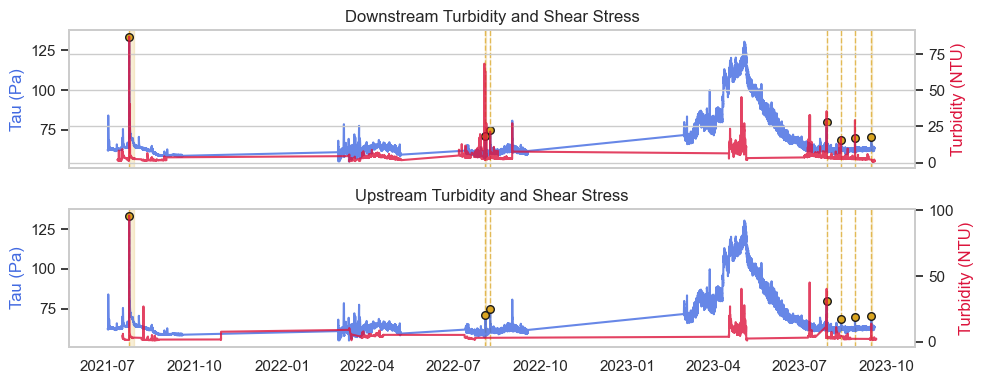

In [8]:
# plot tau and turbidity time series for reaches, with event spans
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
sns.set_theme(style="whitegrid")

colors = ['royalblue', 'crimson']
labels = ['Shear Stress', 'Turbidity']
ylabels = ['Tau (Pa)', 'Turbidity (NTU)']
data = [down_sonde, up_sonde]
titles = ['Downstream Turbidity and Shear Stress', 'Upstream Turbidity and Shear Stress']
plot_windows = peak_tau_df
event_color = 'goldenrod'
event_alpha = 0.18

for i, sonde in enumerate(data):
    ax_tau = ax[i]
    ax_turb = ax_tau.twinx()

    ax_tau.plot(tau.index, tau, label=labels[0], color=colors[0], alpha=0.8)
    ax_tau.set_ylabel(ylabels[0], color=colors[0])
    ax_tau.grid(False)

    ax_turb.plot(sonde.index, sonde['Turbidity FNU'], label=labels[1], color=colors[1], alpha=0.8)
    ax_turb.set_ylabel(ylabels[1], color=colors[1])

    for j, row in plot_windows.iterrows():
        ax_tau.axvspan(
            row['start'],
            row['end'],
            color=event_color,
            alpha=event_alpha,
            zorder=0,
            label='Storm window' if j == 0 else None
        )
        ax_tau.axvline(
            row['peak_time'],
            color=event_color,
            linestyle='--',
            linewidth=1,
            alpha=0.7,
            zorder=1,
            label='Storm peak' if j == 0 else None
        )
        ax_tau.scatter(
            row['peak_time'],
            row['peak_tau'],
            color=event_color,
            edgecolor='k',
            s=30,
            zorder=5
        )

    ax_tau.set_title(titles[i])

plt.grid(False)
plt.tight_layout()
plt.show()

## Refining start and end dates in each event

In [9]:
colors = ['royalblue', 'crimson']
labels = ['Shear Stress', 'Turbidity']
ylabels = ['Tau (Pa)', 'Turbidity (NTU)']
data = [down_sonde, up_sonde]
titles = ['Downstream Turbidity and Shear Stress', 'Upstream Turbidity and Shear Stress']
storm_color = 'goldenrod'
storm_alpha = 0.18

def plot_event_window(storm_idx):
    storm = peak_tau_df.iloc[storm_idx]
    plot_start = storm['start'] - pd.Timedelta(hours=2)
    plot_end = storm['end'] + pd.Timedelta(hours=2)

    fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
    sns.set_theme(style="whitegrid")

    for i, sonde in enumerate(data):
        ax_tau = ax[i]
        ax_turb = ax_tau.twinx()

        ax_tau.plot(tau.index, tau, label=labels[0], color=colors[0], alpha=0.8)
        ax_tau.set_ylabel(ylabels[0], color=colors[0])
        ax_tau.tick_params(axis='x', labelsize=8, rotation=45)
        ax_tau.grid(False)

        ax_turb.plot(sonde.index, sonde['Turbidity FNU'], label=labels[1], color=colors[1], alpha=0.8)
        ax_turb.set_ylabel(ylabels[1], color=colors[1])
        ax_turb.tick_params(axis='x', labelsize=8, rotation=45)
        ax_turb.grid(False)

        ax_tau.axvspan(storm['start'], storm['end'], color=storm_color, alpha=storm_alpha, zorder=0, label='Storm window')
        ax_tau.axvline(storm['peak_time'], color=storm_color, linestyle='--', linewidth=1, alpha=0.7, zorder=1, label='Storm peak')

        ax_tau.set_xlim(plot_start, plot_end)
        ax_tau.set_title(f"{titles[i]} - Storm {storm_idx + 1}")

    plt.grid(False)
    plt.tight_layout()
    plt.show()

Storm 1

start        2021-07-23 12:30:00
peak_time    2021-07-23 16:30:00
end          2021-07-28 11:15:00
Name: 0, dtype: object


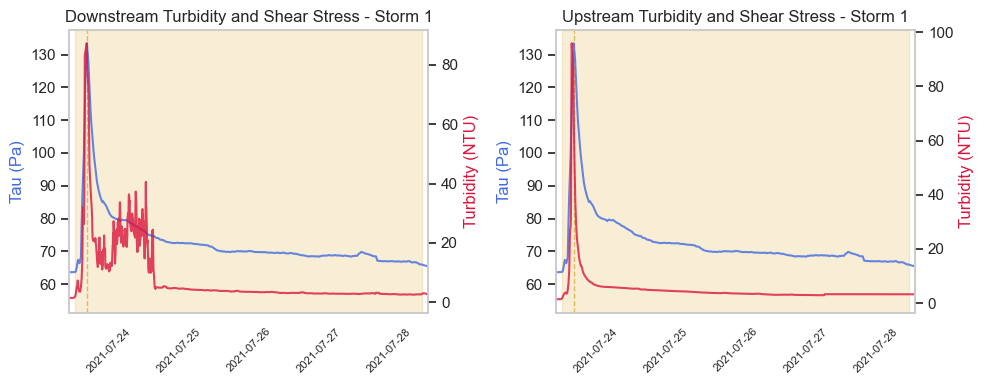

In [10]:
storm_idx = 0  # first event
print(peak_tau_df.loc[peak_tau_df.index[storm_idx], ['start', 'peak_time', 'end']])
plot_event_window(storm_idx)

Storm 2

start        2022-08-03 14:30:00
peak_time    2022-08-03 16:15:00
end          2022-08-03 18:30:00
Name: 1, dtype: object


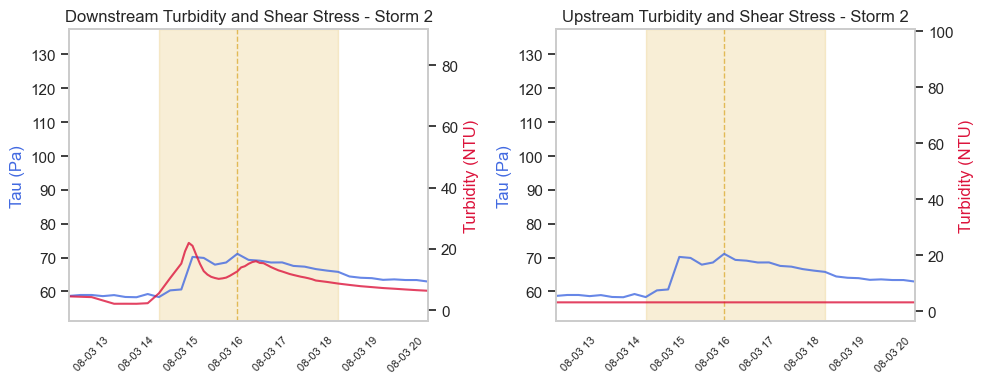

In [11]:
storm_idx = 1
peak_tau_df.loc[peak_tau_df.index[storm_idx], 'start'] = pd.Timestamp('2022-08-03 14:30:00')
peak_tau_df.loc[peak_tau_df.index[storm_idx], 'end'] = pd.Timestamp('2022-08-03 18:30:00')

print(peak_tau_df.loc[peak_tau_df.index[storm_idx], ['start', 'peak_time', 'end']])

plot_event_window(storm_idx)

Storm 3

start        2022-08-08 12:30:00
peak_time    2022-08-08 14:45:00
end          2022-08-08 22:15:00
Name: 2, dtype: object


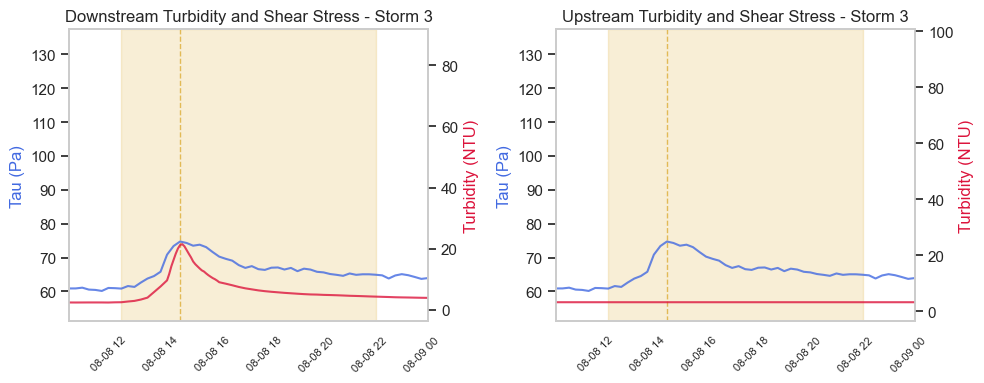

In [12]:
storm_idx = 2
print(peak_tau_df.loc[peak_tau_df.index[storm_idx], ['start', 'peak_time', 'end']])

plot_event_window(storm_idx)

Storm 4

start        2023-07-29 13:00:00
peak_time    2023-07-29 15:45:00
end          2023-07-30 10:30:00
Name: 3, dtype: object


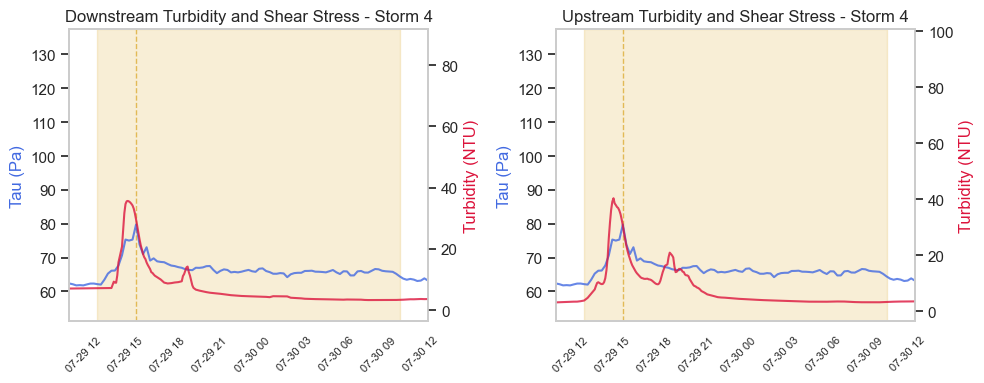

In [13]:
storm_idx = 3
print(peak_tau_df.loc[peak_tau_df.index[storm_idx], ['start', 'peak_time', 'end']])

plot_event_window(storm_idx)

Storm 5

start        2023-08-13 17:15:00
peak_time    2023-08-13 20:45:00
end          2023-08-14 03:15:00
Name: 4, dtype: object


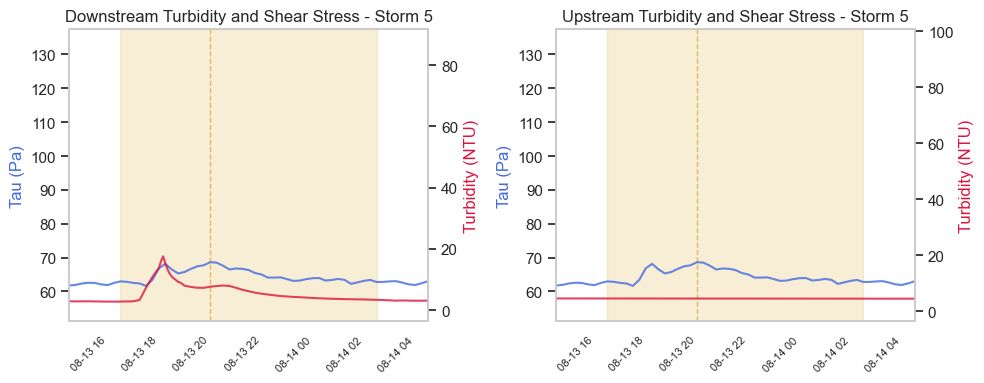

In [14]:
storm_idx = 4
print(peak_tau_df.loc[peak_tau_df.index[storm_idx], ['start', 'peak_time', 'end']])

plot_event_window(storm_idx)

Storm 6

start        2023-08-28 11:30:00
peak_time    2023-08-28 12:15:00
end          2023-08-28 16:30:00
Name: 5, dtype: object


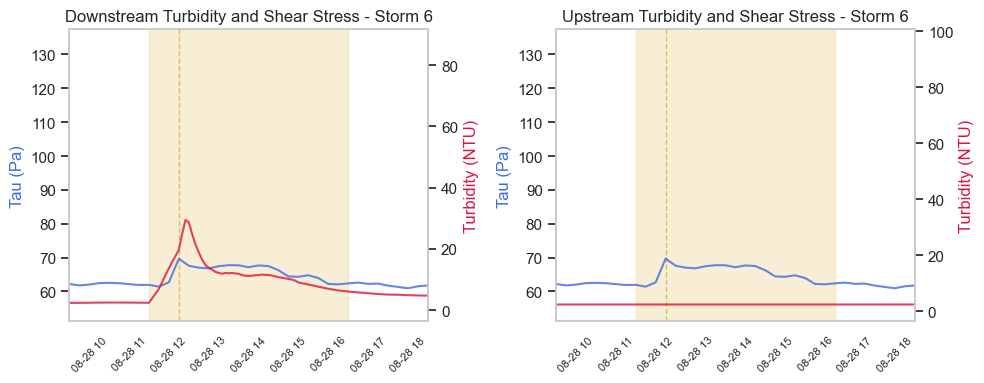

In [15]:
storm_idx = 5
print(peak_tau_df.loc[peak_tau_df.index[storm_idx], ['start', 'peak_time', 'end']])

plot_event_window(storm_idx)

Storm 7

start        2023-09-14 13:00:00
peak_time    2023-09-14 18:00:00
end          2023-09-15 13:00:00
Name: 6, dtype: object


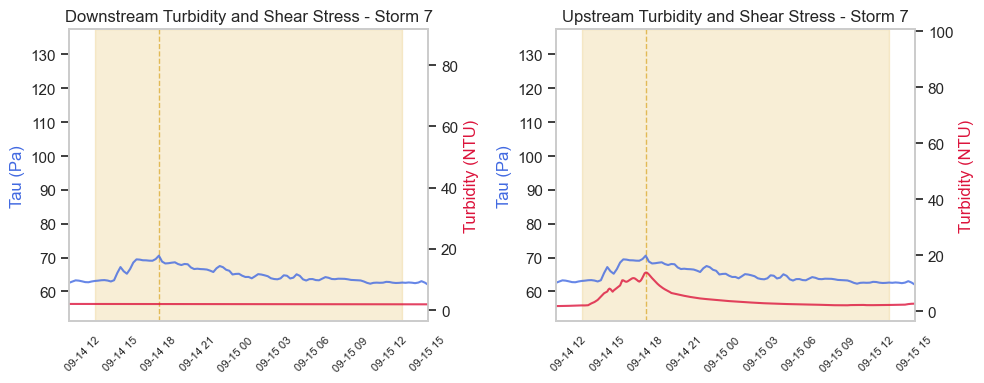

In [16]:
storm_idx = 6
print(peak_tau_df.loc[peak_tau_df.index[storm_idx], ['start', 'peak_time', 'end']])

plot_event_window(storm_idx)

Export event dates to csv

In [17]:
# export events to csv
peak_tau_df.to_csv('summer_events.csv', index=False)

## Critical Shear Stress Exceedance

In [18]:
tauc_exceedance = pd.read_csv('../../data/hydrophones/summer_tauc50_exceedance_times.csv', parse_dates=['Time'], index_col='Time')

In [15]:
tauc_exceedance.index = pd.to_datetime(tauc_exceedance.index)
tauc_exceedance = tauc_exceedance.sort_index()

# group consecutive exceedance timestamps into transport events
expected_step = pd.Timedelta(minutes=15)
# start a new event when the gap between exceedance timestamps is > expected_step
gap = tauc_exceedance.index.to_series().diff()
new_event = gap.gt(expected_step) | gap.isna()
tauc_exceedance["transport_event_id"] = new_event.cumsum()

# summarize each transport event
tauc_exceedance_events = (tauc_exceedance.groupby("transport_event_id").agg(
        start=("Max Amp", lambda x: x.index.min()),
        end=("Max Amp", lambda x: x.index.max()),
        n_points=("Max Amp", "count"),
        max_amp=("Max Amp", "max"),
        max_dmax=("Dmax (mm)", "max")
    )
    .reset_index())

# duration based on timestamps
tauc_exceedance_events["duration"] = (tauc_exceedance_events["end"] - tauc_exceedance_events["start"] + expected_step)
tauc_exceedance_events["duration_hours"] = (
    tauc_exceedance_events["duration"].dt.total_seconds() / 3600)

# get rid of Nan values
tauc_exceedance_events = tauc_exceedance_events.dropna()
tauc_exceedance_events

,transport_event_id,start,end,n_points,max_amp,max_dmax,duration,duration_hours
0,1,2022-08-03 15:01:00,2022-08-03 15:01:00,1,0.022757,65.822866,0 days 00:15:00,0.25
1,2,2022-08-08 14:31:00,2022-08-08 18:01:00,15,0.039280,53.368640,0 days 03:45:00,3.75
2,3,2023-07-29 15:45:00,2023-07-29 15:45:00,1,0.181010,54.039141,0 days 00:15:00,0.25
3,4,2023-09-14 22:45:00,2023-09-14 23:00:00,2,0.027577,43.959000,0 days 00:30:00,0.50


Identify which spring event has tauc exceedance

In [16]:
storms = peak_tau_df.copy()
storms["start"] = pd.to_datetime(storms["start"])
storms["end"] = pd.to_datetime(storms["end"])
storms["peak_time"] = pd.to_datetime(storms["peak_time"])
storm_rows = []

for _, storm in storms.iterrows():
    overlapping_transport = tauc_exceedance_events[
        (tauc_exceedance_events["start"] <= storm["end"]) &
        (tauc_exceedance_events["end"] >= storm["start"])
    ]

    storm_rows.append({
        "storm": storm.get("storm", storm.name),
        "storm_start": storm["start"],
        "storm_peak": storm["peak_time"],
        "storm_end": storm["end"],
        "has_tauc_exceedance": not overlapping_transport.empty,
        "n_transport_events": len(overlapping_transport),
        "n_exceedance_points": overlapping_transport["n_points"].sum() if not overlapping_transport.empty else 0,
        "total_exceedance_hours": overlapping_transport["duration_hours"].sum() if not overlapping_transport.empty else 0,
        "max_Dmax_mm": overlapping_transport["max_dmax"].max() if not overlapping_transport.empty else np.nan
    })

storm_transport_summary = pd.DataFrame(storm_rows)
storm_transport_summary

,storm,storm_start,storm_peak,storm_end,has_tauc_exceedance,n_transport_events,n_exceedance_points,total_exceedance_hours,max_Dmax_mm
0,st1,2021-07-23 12:30:00,2021-07-23 16:30:00,2021-07-28 11:15:00,False,0,0,0.00,NaN
1,st2,2022-08-03 14:30:00,2022-08-03 16:15:00,2022-08-03 18:30:00,True,1,1,0.25,65.822866
2,st3,2022-08-08 12:30:00,2022-08-08 14:45:00,2022-08-08 22:15:00,True,1,15,3.75,53.368640
3,st4,2023-07-29 13:00:00,2023-07-29 15:45:00,2023-07-30 10:30:00,True,1,1,0.25,54.039141
4,st5,2023-08-13 17:15:00,2023-08-13 20:45:00,2023-08-14 03:15:00,False,0,0,0.00,NaN
5,st6,2023-08-28 11:30:00,2023-08-28 12:15:00,2023-08-28 16:30:00,False,0,0,0.00,NaN
6,st7,2023-09-14 13:00:00,2023-09-14 18:00:00,2023-09-15 13:00:00,True,1,2,0.50,43.959000


Plot tauc exceedance during events

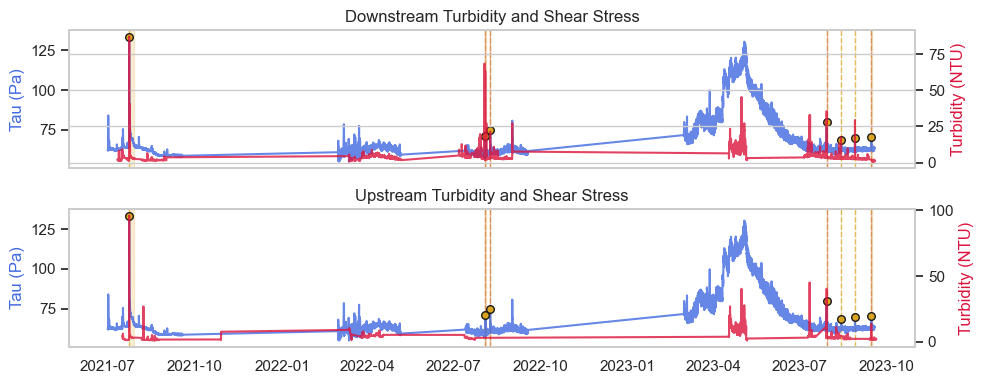

In [17]:
# plot tau and turbidity time series for reaches, with event spans
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
sns.set_theme(style="whitegrid")

colors = ['royalblue', 'crimson']
labels = ['Shear Stress', 'Turbidity']
ylabels = ['Tau (Pa)', 'Turbidity (NTU)']
data = [down_sonde, up_sonde]
titles = ['Downstream Turbidity and Shear Stress', 'Upstream Turbidity and Shear Stress']
plot_windows = peak_tau_df
event_color = 'goldenrod'
event_alpha = 0.18
transport_color = 'indianred'

for i, sonde in enumerate(data):
    ax_tau = ax[i]
    ax_turb = ax_tau.twinx()

    ax_tau.plot(tau.index, tau, label=labels[0], color=colors[0], alpha=0.8)
    ax_tau.set_ylabel(ylabels[0], color=colors[0])
    ax_tau.grid(False)

    ax_turb.plot(sonde.index, sonde['Turbidity FNU'], label=labels[1], color=colors[1], alpha=0.8)
    ax_turb.set_ylabel(ylabels[1], color=colors[1])

    for j, row in plot_windows.iterrows():
        ax_tau.axvspan(
            row['start'],
            row['end'],
            color=event_color,
            alpha=event_alpha,
            zorder=0,
            label='Storm window' if j == 0 else None
        )
        ax_tau.axvline(
            row['peak_time'],
            color=event_color,
            linestyle='--',
            linewidth=1,
            alpha=0.7,
            zorder=1,
            label='Storm peak' if j == 0 else None
        )
        ax_tau.scatter(
            row['peak_time'],
            row['peak_tau'],
            color=event_color,
            edgecolor='k',
            s=30,
            zorder=5
        )

    # tauc exceedance windows
    for j, row in tauc_exceedance_events.iterrows():
        ax_tau.axvspan(
            row["start"], row["end"],
            color=transport_color,
            alpha=0.4,
            zorder=1,
            label="τc exceedance" if j == 0 else None
        )

    ax_tau.set_title(titles[i])

plt.grid(False)
plt.tight_layout()
plt.show()

In [18]:
storm_transport_summary.to_csv('summer_event_tauc_summary.csv', index=False)